#**Telecom X — Análise de Evasão de Clientes (Churn)**


In [16]:
# Importação dos dados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [17]:
# Carregamento dos dados - Extração

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [18]:
# Visão geral dos dados

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [19]:
# Verificação de valores nulos

df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [20]:
# Normalização de colunas alinhadas (json)

customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

In [21]:
# Consolidação dos dados

df_clean = pd.concat(
    [
        df[['customerID', 'Churn']],
        customer_df,
        phone_df,
        internet_df,
        account_df
    ],
    axis=1
)

df_clean.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [22]:
# Padronização colunas e valores

# Padronizar nomes das colunas
df_clean.columns = (
    df_clean.columns
    .str.lower()
    .str.replace(' ', '_')
)

# Substituir strings vazias por NaN
df_clean.replace(" ", np.nan, inplace=True)

In [23]:
# Conversão de tipos e tratamento de inconsistências

# Converter charges.total para numérico
df_clean['charges.total'] = pd.to_numeric(
    df_clean['charges.total'],
    errors='coerce'
)

# Preencher nulos com a mediana
df_clean['charges.total'].fillna(
    df_clean['charges.total'].median(),
    inplace=True
)


/tmp/ipython-input-1834139834.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['charges.total'].fillna(


In [24]:
# Padronização de dados textuais

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip().str.lower()


In [25]:
#Correção de inconsistências lógicas

cols_services = [
    'onlinesecurity', 'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies'
]

for col in cols_services:
    df_clean[col] = df_clean[col].replace('no internet service', 'no')


In [26]:
# Tratamento de duplicados

df_clean.drop_duplicates(inplace=True)


In [27]:
#Verificação final de qualidade

df_clean.info()
df_clean.isnull().sum()
df_clean.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7267 non-null   object 
 1   churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   seniorcitizen     7267 non-null   int64  
 4   partner           7267 non-null   object 
 5   dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   phoneservice      7267 non-null   object 
 8   multiplelines     7267 non-null   object 
 9   internetservice   7267 non-null   object 
 10  onlinesecurity    7267 non-null   object 
 11  onlinebackup      7267 non-null   object 
 12  deviceprotection  7267 non-null   object 
 13  techsupport       7267 non-null   object 
 14  streamingtv       7267 non-null   object 
 15  streamingmovies   7267 non-null   object 
 16  contract          7267 non-null   object 


np.int64(0)

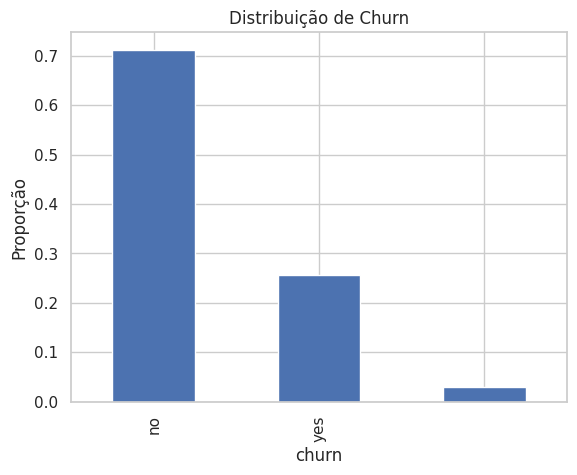

In [28]:
# Análise descritiva EDA
# Distribuição de Churn

df_clean['churn'].value_counts(normalize=True).plot(
    kind='bar',
    title='Distribuição de Churn',
    ylabel='Proporção'
)
plt.show()


### Distribuição de Churn

O gráfico acima apresenta a distribuição proporcional da variável alvo `churn`.

Observa-se que a maioria dos clientes permanece na empresa, representando cerca de 70% da base, enquanto aproximadamente 26% dos clientes cancelaram o serviço.

Esse comportamento indica um leve desbalanceamento entre as classes, cenário comum em problemas de churn. Apesar da menor proporção de cancelamentos, a evasão representa um impacto significativo para o negócio, justificando a necessidade de identificar os fatores associados ao churn.


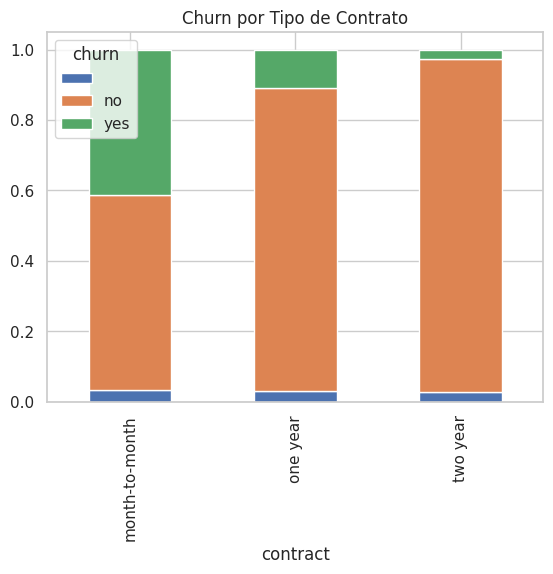

In [29]:
#Churn por tipo de contrato

churn_contract = (
    df_clean
    .groupby('contract')['churn']
    .value_counts(normalize=True)
    .unstack()
)

churn_contract.plot(
    kind='bar',
    stacked=True,
    title='Churn por Tipo de Contrato'
)
plt.show()


Clientes com contratos do tipo month-to-month apresentam uma taxa de churn significativamente maior quando comparados aos contratos anuais e bienais. Isso sugere que a ausência de vínculo de longo prazo aumenta a propensão ao cancelamento.

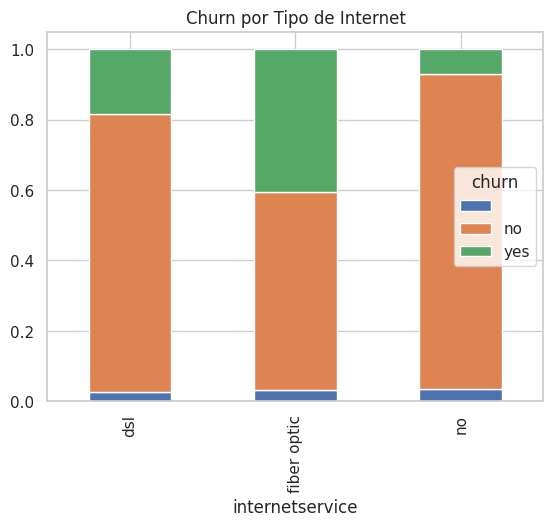

In [30]:
# Churn por tipo de internet

churn_internet = (
    df_clean
    .groupby('internetservice')['churn']
    .value_counts(normalize=True)
    .unstack()
)

churn_internet.plot(
    kind='bar',
    stacked=True,
    title='Churn por Tipo de Internet'
)
plt.show()


Clientes com Fiber Optic apresentam a maior taxa de churn. O serviço DSL possui uma taxa de evasão menor. Clientes sem serviço de internet demonstram o menor índice de cancelamento.

Esse comportamento pode indicar possíveis problemas relacionados ao serviço de fibra óptica, como:

Instabilidade,

Expectativa elevada dos clientes,

Preço mais alto em relação ao valor percebido.

Insight-chave:

O serviço de Fiber Optic concentra o maior risco de churn e deve ser investigado em profundidade.

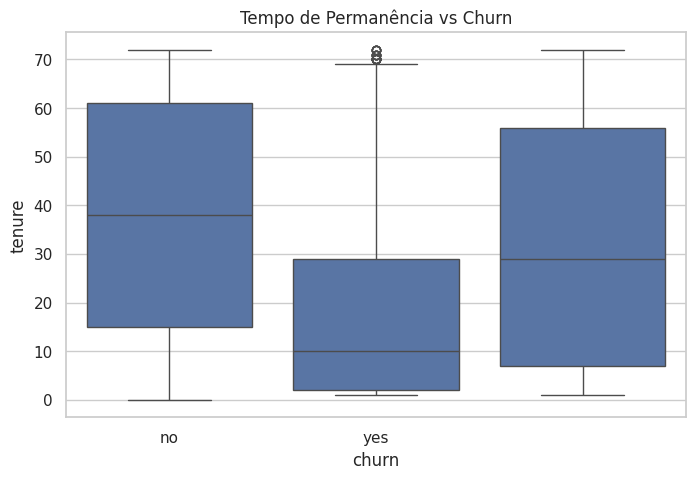

In [31]:
#Churn tempo de permanência

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_clean,
    x='churn',
    y='tenure'
)
plt.title('Tempo de Permanência vs Churn')
plt.show()


Observa-se uma diferença clara no tempo de permanência entre clientes que cancelaram e os que permaneceram ativos.

Clientes com **churn = yes** apresentam, em geral, um **tempo de permanência significativamente menor**, concentrando-se nos primeiros meses de contrato. Isso indica que grande parte dos cancelamentos ocorre no início do relacionamento com a empresa.

Por outro lado, clientes com **churn = no** possuem **tenure mais elevado**, com maior dispersão e medianas mais altas, demonstrando maior fidelização ao longo do tempo.

Clientes nos **primeiros meses de contrato** representam o **maior risco de churn**, sugerindo a necessidade de ações de retenção precoce, como acompanhamento inicial, melhoria na experiência onboarding e ofertas direcionadas nos primeiros ciclos.


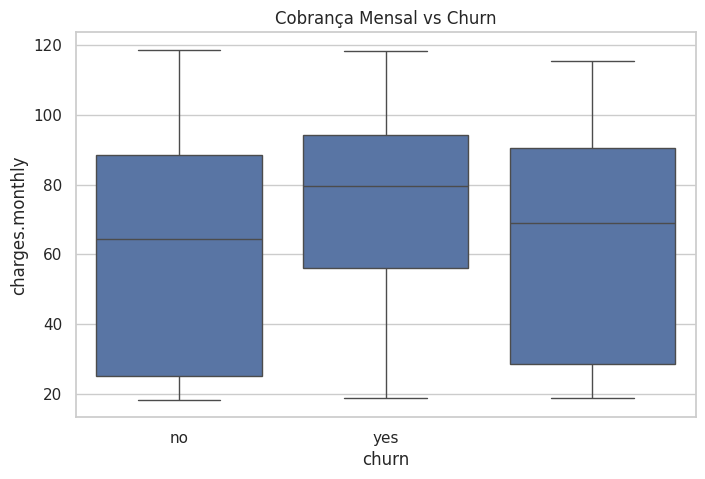

In [32]:
#Churn por valor mensal

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_clean,
    x='churn',
    y='charges.monthly'
)
plt.title('Cobrança Mensal vs Churn')
plt.show()


Observa-se que clientes que cancelaram o serviço (**churn = yes**) apresentam, em média, **valores de cobrança mensal mais elevados** em comparação aos clientes que permaneceram (**churn = no**).

O boxplot indica que:
- A mediana da cobrança mensal é maior entre os clientes que churnaram.
- Há uma concentração maior de churn em faixas de preço mais altas.
- Clientes com valores mensais mais baixos tendem a permanecer por mais tempo na base.

**Insight-chave:**

A cobrança mensal elevada é um fator fortemente associado ao churn, sugerindo que **preço percebido vs. valor entregue** pode influenciar diretamente a decisão de cancelamento. Estratégias como revisão de planos, benefíc


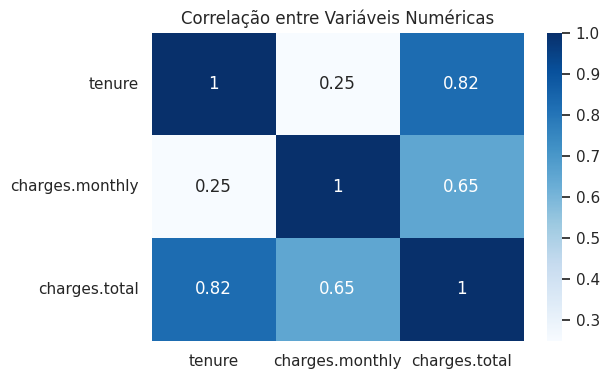

In [33]:
# Análise de correlação (variáveis numéricas)

plt.figure(figsize=(6,4))
sns.heatmap(
    df_clean[['tenure', 'charges.monthly', 'charges.total']].corr(),
    annot=True,
    cmap='Blues'
)
plt.title('Correlação entre Variáveis Numéricas')
plt.show()


O mapa de calor evidencia a relação entre as variáveis **tempo de permanência (tenure)**, **cobrança mensal (charges.monthly)** e **cobrança total (charges.total)**.

Principais observações:
- Existe uma **forte correlação positiva entre tenure e charges.total**, o que é esperado, já que clientes com maior tempo de contrato acumulam maior valor total pago.
- A correlação entre **charges.monthly e charges.total** também é positiva, indicando que valores mensais mais altos contribuem para um maior gasto total ao longo do tempo.
- A correlação entre **tenure e charges.monthly** é mais fraca, sugerindo que o valor mensal não depende diretamente do tempo de permanência do cliente.

**Insight-chave:**

O **tempo de permanência** é o principal fator associado ao valor total gerado pelo cliente, reforçando a importância de estratégias de retenção para aumentar o **lifetime value (LTV)** da base.


In [34]:
# Definição de Target e Features (pronto para ML)

target = 'churn'

X = df_clean.drop(columns=['customerid', 'churn'])
y = df_clean[target]

X.head()


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges.monthly,charges.total
0,female,0,yes,yes,9,yes,no,dsl,no,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30
1,male,0,no,no,9,yes,yes,dsl,no,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40
2,male,0,no,no,4,yes,no,fiber optic,no,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,male,1,yes,no,13,yes,no,fiber optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,female,1,yes,no,3,yes,no,fiber optic,no,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40


### Conclusão Geral

A análise indica que o **churn está fortemente associado ao tipo de serviço, tempo de permanência e valor mensal**.  
Clientes com **Fiber Optic**, **menor tenure** e **cobranças mensais mais altas** apresentam maior propensão ao cancelamento.  

Esses resultados reforçam a importância de **ações de retenção nos primeiros meses de contrato** e de uma **avaliação mais profunda do serviço de fibra óptica**, visando reduzir a evasão e aumentar o valor gerado ao longo do tempo.
